<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_wave_to_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D13_WAVE_TO_MEMORY — Wave Signal Writes Memory

This notebook tests whether a transmitted wave signal can be decoded and written into bounded memory slots.

Expected result:

INPUT_SEQUENCE = 10110101  
DECODED_SEQUENCE = 10110101  
STORED_SEQUENCE = 10110101  

STATE = MEMORY_WRITE_LOCKED

D13_WAVE_TO_MEMORY — Wave Signal Writes Memory

STATE: MEMORY_WRITE_LOCKED
input sequence: 10110101
decoded sequence: 10110101
stored sequence: 10110101
decode accuracy: 1.0
memory accuracy: 1.0


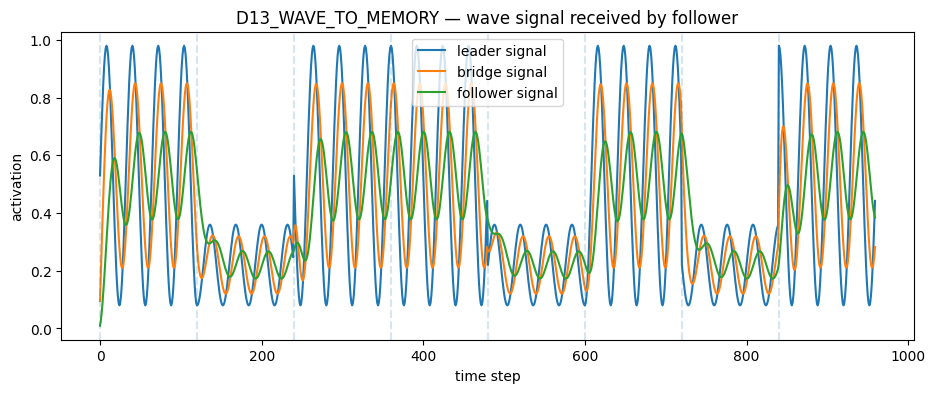

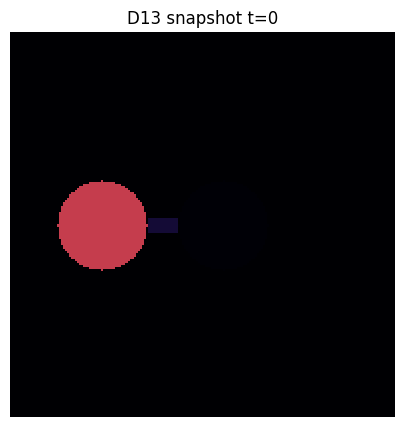

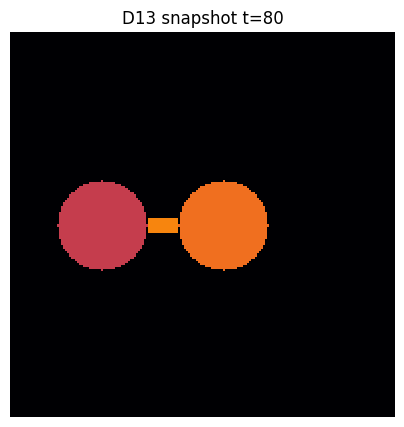

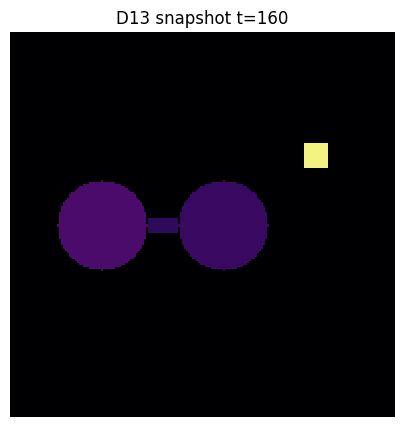

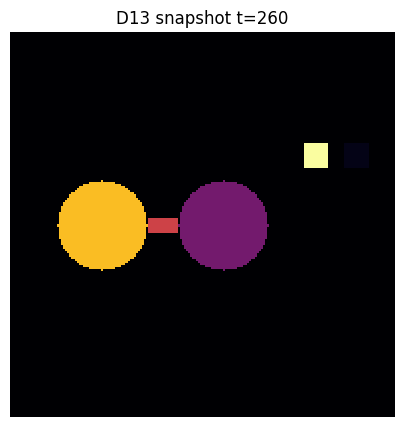

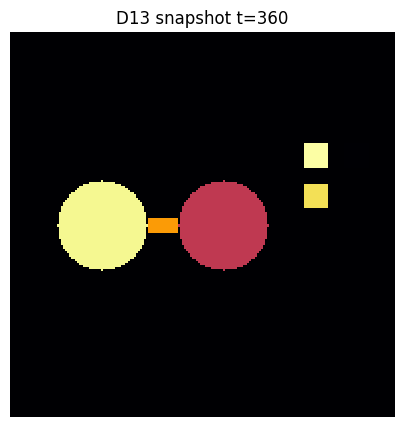

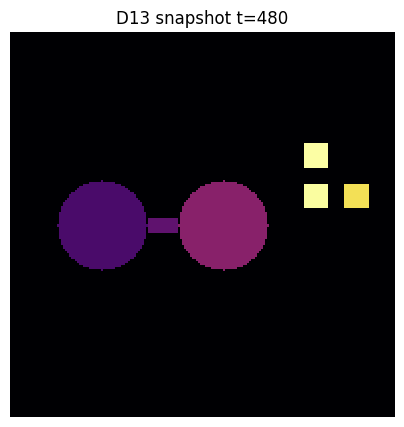

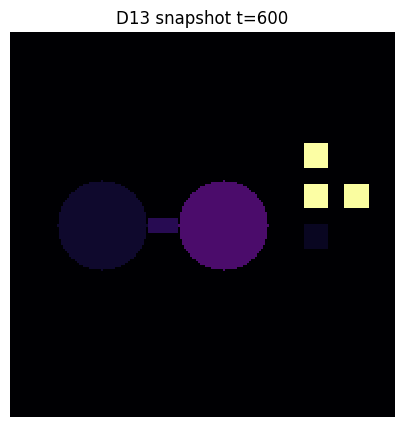

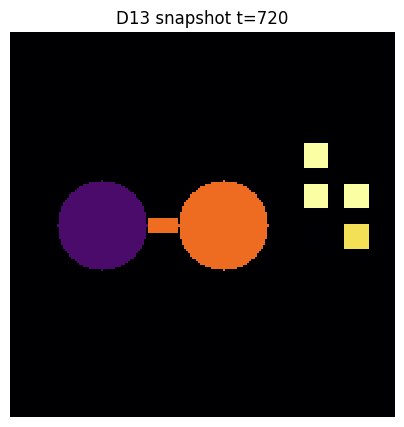

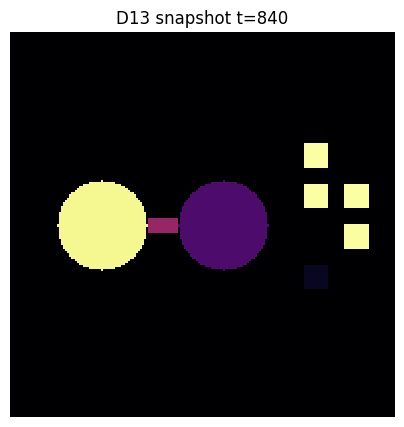

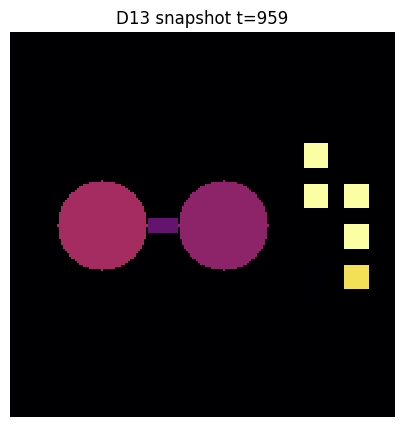

Decoded bits:


,STATE,BIT_INDEX,INPUT_BIT,RECEIVED_MEAN,DECODED_BIT,MEMORY_VALUE_AFTER_WRITE,MATCH
0,D13_WAVE_TO_MEMORY,0,1,0.541,1,0.92,1
1,D13_WAVE_TO_MEMORY,1,0,0.218,0,0.06,1
2,D13_WAVE_TO_MEMORY,2,1,0.515,1,0.92,1
3,D13_WAVE_TO_MEMORY,3,1,0.540,1,0.92,1
4,D13_WAVE_TO_MEMORY,4,0,0.225,0,0.06,1
5,D13_WAVE_TO_MEMORY,5,1,0.518,1,0.92,1
6,D13_WAVE_TO_MEMORY,6,0,0.218,0,0.06,1
7,D13_WAVE_TO_MEMORY,7,1,0.538,1,0.92,1


Memory slots:


,STATE,MEMORY_SLOT,INPUT_BIT,STORED_VALUE,STORED_BIT,MATCH
0,D13_WAVE_TO_MEMORY,0,1,1.000,1,1
1,D13_WAVE_TO_MEMORY,1,0,0.000,0,1
2,D13_WAVE_TO_MEMORY,2,1,1.000,1,1
3,D13_WAVE_TO_MEMORY,3,1,1.000,1,1
4,D13_WAVE_TO_MEMORY,4,0,0.000,0,1
5,D13_WAVE_TO_MEMORY,5,1,1.000,1,1
6,D13_WAVE_TO_MEMORY,6,0,0.005,0,1
7,D13_WAVE_TO_MEMORY,7,1,0.920,1,1


Summary:


,STATE,RESULT,INPUT_SEQUENCE,DECODED_SEQUENCE,STORED_SEQUENCE,DECODE_ACCURACY,MEMORY_ACCURACY,BIT_LEN,DECODE_DELAY,DECODE_THRESHOLD
0,D13_WAVE_TO_MEMORY,MEMORY_WRITE_LOCKED,10110101,10110101,10110101,1.0,1.0,120,35,0.38


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def make_wave_memory_masks(size=190, radius=22, memory_slots=8):
    Y, X = np.ogrid[:size, :size]

    center_leader = (45, size // 2)
    center_follower = (105, size // 2)

    dist_leader = np.sqrt((X - center_leader[0]) ** 2 + (Y - center_leader[1]) ** 2)
    dist_follower = np.sqrt((X - center_follower[0]) ** 2 + (Y - center_follower[1]) ** 2)

    leader_cell = dist_leader <= radius
    follower_cell = dist_follower <= radius

    bridge = (
        (Y >= size // 2 - 3)
        & (Y <= size // 2 + 3)
        & (X > center_leader[0] + radius)
        & (X < center_follower[0] - radius)
    )

    memory_masks = []

    start_x = 145
    start_y = 55
    slot_size = 12
    gap = 8

    for i in range(memory_slots):
        row = i // 2
        col = i % 2

        x0 = start_x + col * (slot_size + gap)
        y0 = start_y + row * (slot_size + gap)

        slot = (
            (X >= x0)
            & (X < x0 + slot_size)
            & (Y >= y0)
            & (Y < y0 + slot_size)
        )

        memory_masks.append(slot)

    return leader_cell, follower_cell, bridge, memory_masks


def render_wave_memory_field(
    size,
    leader_cell,
    follower_cell,
    bridge,
    memory_masks,
    leader_activation,
    bridge_activation,
    follower_activation,
    memory_values,
):
    field = np.zeros((size, size), dtype=float)

    field[leader_cell] = leader_activation
    field[bridge] = bridge_activation
    field[follower_cell] = follower_activation

    for value, mask in zip(memory_values, memory_masks):
        field[mask] = value

    return field


def bistable_memory_update(memory_values, strength=0.045):
    """
    Bistable memory rule.

    Values below 0.5 move toward 0.
    Values above 0.5 move toward 1.

    This prevents weak zero values from growing into false 1 values.
    """
    memory_values = (
        memory_values
        + strength
        * memory_values
        * (1 - memory_values)
        * (memory_values - 0.5)
    )

    return np.clip(memory_values, 0, 1)


def run_wave_to_memory(
    size=190,
    bit_sequence=(1, 0, 1, 1, 0, 1, 0, 1),
    bit_len=120,
    carrier_period=32,
    bridge_gain=0.18,
    follower_gain=0.10,
    low_bit_gain=0.28,
    high_bit_gain=0.90,
    base_signal=0.08,
    decode_delay=35,
    decode_threshold=0.38,
    write_high=0.92,
    write_low=0.06,
    memory_hold_strength=0.045,
):
    bit_sequence = np.array(bit_sequence, dtype=int)
    steps = len(bit_sequence) * bit_len

    leader_cell, follower_cell, bridge, memory_masks = make_wave_memory_masks(
        size=size,
        memory_slots=len(bit_sequence),
    )

    bridge_state = 0.0
    follower_state = 0.0

    memory_values = np.zeros(len(bit_sequence), dtype=float)

    omega = 2 * np.pi / carrier_period

    history = []
    decoded_rows = []
    snapshots = {}

    for t in range(steps):
        bit_index = min(t // bit_len, len(bit_sequence) - 1)
        bit = int(bit_sequence[bit_index])

        carrier = 0.5 + 0.5 * np.sin(omega * t)

        if bit == 1:
            bit_gain = high_bit_gain
        else:
            bit_gain = low_bit_gain

        leader_activation = base_signal + bit_gain * carrier

        bridge_state += bridge_gain * (leader_activation - bridge_state)
        follower_state += follower_gain * (bridge_state - follower_state)

        leader_activation = float(np.clip(leader_activation, 0, 1))
        bridge_activation = float(np.clip(bridge_state, 0, 1))
        follower_activation = float(np.clip(follower_state, 0, 1))

        # Fixed memory rule:
        # 0 stays 0, 1 stays 1.
        memory_values = bistable_memory_update(
            memory_values,
            strength=memory_hold_strength,
        )

        history.append(
            {
                "t": t,
                "bit_index": bit_index,
                "input_bit": bit,
                "leader_activation": leader_activation,
                "bridge_activation": bridge_activation,
                "follower_activation": follower_activation,
            }
        )

        # Decode and write memory at the end of each bit window.
        if (t + 1) % bit_len == 0:
            start = bit_index * bit_len + decode_delay
            end = (bit_index + 1) * bit_len

            history_df_temp = pd.DataFrame(history)
            sample = history_df_temp.iloc[start:end]

            received_mean = float(sample["follower_activation"].mean())
            decoded_bit = 1 if received_mean >= decode_threshold else 0

            if decoded_bit == 1:
                memory_values[bit_index] = write_high
            else:
                memory_values[bit_index] = write_low

            decoded_rows.append(
                {
                    "STATE": "D13_WAVE_TO_MEMORY",
                    "BIT_INDEX": bit_index,
                    "INPUT_BIT": bit,
                    "RECEIVED_MEAN": round(received_mean, 3),
                    "DECODED_BIT": decoded_bit,
                    "MEMORY_VALUE_AFTER_WRITE": round(float(memory_values[bit_index]), 3),
                    "MATCH": int(decoded_bit == bit),
                }
            )

        if t in [0, 80, 160, 260, 360, 480, 600, 720, 840, steps - 1]:
            snapshots[t] = render_wave_memory_field(
                size=size,
                leader_cell=leader_cell,
                follower_cell=follower_cell,
                bridge=bridge,
                memory_masks=memory_masks,
                leader_activation=leader_activation,
                bridge_activation=bridge_activation,
                follower_activation=follower_activation,
                memory_values=memory_values,
            )

    history = pd.DataFrame(history)
    df_decode = pd.DataFrame(decoded_rows)

    stored_bits = []
    for value in memory_values:
        stored_bits.append(1 if value >= 0.5 else 0)

    input_sequence = "".join(str(x) for x in bit_sequence)
    decoded_sequence = "".join(str(x) for x in df_decode["DECODED_BIT"].values)
    stored_sequence = "".join(str(x) for x in stored_bits)

    decode_accuracy = float(df_decode["MATCH"].mean())
    memory_accuracy = float(np.mean(bit_sequence == np.array(stored_bits)))

    if decode_accuracy == 1.0 and memory_accuracy == 1.0:
        result = "MEMORY_WRITE_LOCKED"
    elif decode_accuracy >= 0.75 and memory_accuracy >= 0.75:
        result = "PARTIAL_MEMORY_WRITE"
    else:
        result = "MEMORY_WRITE_FAILED"

    summary = pd.DataFrame(
        [
            {
                "STATE": "D13_WAVE_TO_MEMORY",
                "RESULT": result,
                "INPUT_SEQUENCE": input_sequence,
                "DECODED_SEQUENCE": decoded_sequence,
                "STORED_SEQUENCE": stored_sequence,
                "DECODE_ACCURACY": round(decode_accuracy, 3),
                "MEMORY_ACCURACY": round(memory_accuracy, 3),
                "BIT_LEN": bit_len,
                "DECODE_DELAY": decode_delay,
                "DECODE_THRESHOLD": decode_threshold,
            }
        ]
    )

    df_memory = pd.DataFrame(
        [
            {
                "STATE": "D13_WAVE_TO_MEMORY",
                "MEMORY_SLOT": i,
                "INPUT_BIT": int(bit_sequence[i]),
                "STORED_VALUE": round(float(memory_values[i]), 3),
                "STORED_BIT": int(stored_bits[i]),
                "MATCH": int(stored_bits[i] == bit_sequence[i]),
            }
            for i in range(len(bit_sequence))
        ]
    )

    return history, snapshots, df_decode, df_memory, summary


history, snapshots, df_decode, df_memory, summary = run_wave_to_memory()

print("STATE:", summary["RESULT"].iloc[0])
print("input sequence:", summary["INPUT_SEQUENCE"].iloc[0])
print("decoded sequence:", summary["DECODED_SEQUENCE"].iloc[0])
print("stored sequence:", summary["STORED_SEQUENCE"].iloc[0])
print("decode accuracy:", summary["DECODE_ACCURACY"].iloc[0])
print("memory accuracy:", summary["MEMORY_ACCURACY"].iloc[0])

plt.figure(figsize=(11, 4))
plt.plot(history["t"], history["leader_activation"], label="leader signal")
plt.plot(history["t"], history["bridge_activation"], label="bridge signal")
plt.plot(history["t"], history["follower_activation"], label="follower signal")

for bit_start in range(0, len(history), 120):
    plt.axvline(bit_start, linestyle="--", alpha=0.18)

plt.title("D13_WAVE_TO_MEMORY — wave signal received by follower")
plt.xlabel("time step")
plt.ylabel("activation")
plt.legend()
plt.show()

for t, snap in snapshots.items():
    plt.figure(figsize=(5, 5))
    plt.imshow(snap, cmap="inferno", vmin=0, vmax=1, interpolation="nearest")
    plt.title(f"D13 snapshot t={t}")
    plt.axis("off")
    plt.show()

print("Decoded bits:")
display(df_decode)

print("Memory slots:")
display(df_memory)

print("Summary:")
display(summary)

In [2]:
df_memory

,STATE,MEMORY_SLOT,INPUT_BIT,STORED_VALUE,STORED_BIT,MATCH
0,D13_WAVE_TO_MEMORY,0,1,1.000,1,1
1,D13_WAVE_TO_MEMORY,1,0,0.000,0,1
2,D13_WAVE_TO_MEMORY,2,1,1.000,1,1
3,D13_WAVE_TO_MEMORY,3,1,1.000,1,1
4,D13_WAVE_TO_MEMORY,4,0,0.000,0,1
5,D13_WAVE_TO_MEMORY,5,1,1.000,1,1
6,D13_WAVE_TO_MEMORY,6,0,0.005,0,1
7,D13_WAVE_TO_MEMORY,7,1,0.920,1,1


In [3]:
summary

,STATE,RESULT,INPUT_SEQUENCE,DECODED_SEQUENCE,STORED_SEQUENCE,DECODE_ACCURACY,MEMORY_ACCURACY,BIT_LEN,DECODE_DELAY,DECODE_THRESHOLD
0,D13_WAVE_TO_MEMORY,MEMORY_WRITE_LOCKED,10110101,10110101,10110101,1.0,1.0,120,35,0.38
